<a href="https://colab.research.google.com/github/mohamadatashfaraz4-netizen/master-thesis/blob/main/7_TabPFN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q tabpfn pandas scikit-learn openpyxl matplotlib

In [ ]:
from google.colab import files

# Excel-Datei hochladen
uploaded = files.upload()

Saving credit_card_corrupted_all_errors.xlsx to credit_card_corrupted_all_errors (3).xlsx


In [ ]:
import os
from getpass import getpass

os.environ["TABPFN_TOKEN"] = getpass("Geben Sie Ihr TABPFN-Token ein: ")

Geben Sie Ihr TABPFN-Token ein: ··········


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from sklearn.impute import SimpleImputer

from tabpfn import TabPFNClassifier
from google.colab import files

In [ ]:
# Beschädigten Credit-Card-Datensatz laden
df = pd.read_excel("credit_card_corrupted_all_errors.xlsx")

# Spaltennamen standardisieren
df.columns = (
    df.columns
      .astype(str)
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
)

# Zielspalte definieren
target_col = "default_payment_next_month"

# Prüfen, ob die Zielspalte vorhanden ist
if target_col not in df.columns:
    raise ValueError(f"Target column not found: {target_col}")

print("Shape before target cleaning:", df.shape)
print("Missing values in target before cleaning:", df[target_col].isna().sum())

# Zeilen mit fehlender Zielvariable entfernen
df = df.dropna(subset=[target_col])

# Zielvariable als Integer setzen
df[target_col] = df[target_col].astype(int)

print("Shape after target cleaning:", df.shape)
print("Missing values in target after cleaning:", df[target_col].isna().sum())

# Zielverteilung anzeigen
print("\nTarget distribution:")
print(df[target_col].value_counts())
print(df[target_col].value_counts(normalize=True))

Shape before target cleaning: (30300, 25)
Missing values in target before cleaning: 1541
Shape after target cleaning: (28759, 25)
Missing values in target after cleaning: 0

Target distribution:
default_payment_next_month
0    21892
1     6867
Name: count, dtype: int64
default_payment_next_month
0    0.761223
1    0.238777
Name: proportion, dtype: float64


In [ ]:
# Stichprobe für schnellere Ausführung in Colab
sample_size = min(2000, len(df))

# Geschichtete Stichprobe nach Zielvariable erstellen
df_sample = (
    df.groupby(target_col, group_keys=False)
      .apply(
          lambda group: group.sample(
              n=max(1, int(sample_size * len(group) / len(df))),
              random_state=42
          )
      )
)

# Falls durch Rundung weniger Zeilen entstehen, zusätzliche Zeilen ergänzen
if len(df_sample) < sample_size:
    remaining = df.drop(index=df_sample.index)
    additional = remaining.sample(
        n=sample_size - len(df_sample),
        random_state=42
    )
    df_sample = pd.concat([df_sample, additional])

# Falls durch Rundung mehr Zeilen entstehen, auf sample_size begrenzen
df_sample = df_sample.sample(
    n=sample_size,
    random_state=42
)

print("Sample shape:", df_sample.shape)
print("\nSample target distribution:")
print(df_sample[target_col].value_counts())
print(df_sample[target_col].value_counts(normalize=True))

Sample shape: (2000, 25)

Sample target distribution:
default_payment_next_month
0    1522
1     478
Name: count, dtype: int64
default_payment_next_month
0    0.761
1    0.239
Name: proportion, dtype: float64


/tmp/ipykernel_14623/2997124592.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


In [ ]:
# Merkmale und Zielvariable trennen
X = df_sample.drop(columns=[target_col])
y = df_sample[target_col]

# ID-Spalte entfernen, falls vorhanden
if "id" in X.columns:
    X = X.drop(columns=["id"])

print("X shape:", X.shape)
print("y shape:", y.shape)

# Kontrolle fehlender Werte
print("Missing values in X:", int(X.isna().sum().sum()))
print("Missing values in y:", int(y.isna().sum()))

X shape: (2000, 23)
y shape: (2000,)
Missing values in X: 2222
Missing values in y: 0


In [ ]:
# Daten in Trainings- und Testdaten aufteilen
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.33,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1340, 23)
Test shape: (660, 23)


In [ ]:
# TabPFN initialisieren und trainieren
model = TabPFNClassifier()

model.fit(X_train, y_train)

TabPFNClassifier()

In [ ]:
# Vorhersagen und Wahrscheinlichkeiten erzeugen
predictions = model.predict(X_test)
probabilities = model.predict_proba(X_test)[:, 1]

# Modellleistung bewerten
accuracy = accuracy_score(y_test, predictions)
roc_auc = roc_auc_score(y_test, probabilities)

print("Accuracy:", accuracy)
print("ROC AUC:", roc_auc)

print("\nClassification report:")
print(classification_report(y_test, predictions))

Accuracy: 0.7924242424242425
ROC AUC: 0.7568082101971858

Classification report:
              precision    recall  f1-score   support

           0       0.82      0.94      0.87       502
           1       0.62      0.34      0.44       158

    accuracy                           0.79       660
   macro avg       0.72      0.64      0.65       660
weighted avg       0.77      0.79      0.77       660



In [ ]:
# Maximale vorhergesagte Klassenwahrscheinlichkeit berechnen
proba_all = model.predict_proba(X_test)
max_probability = proba_all.max(axis=1)

# Prüftabelle für unsichere Fälle erstellen
uncertain_cases = X_test.copy()
uncertain_cases["true_label"] = y_test.values
uncertain_cases["prediction"] = predictions
uncertain_cases["probability_class_1"] = probabilities
uncertain_cases["max_probability"] = max_probability

# Fälle mit niedriger Konfidenz für manuelle Prüfung markieren
threshold = 0.70
uncertain_cases["needs_review"] = uncertain_cases["max_probability"] < threshold

# Unsichere Fälle sortieren
uncertain_cases_sorted = uncertain_cases.sort_values(
    by="max_probability",
    ascending=True
)

print("Number of uncertain cases:")
print(uncertain_cases_sorted["needs_review"].sum())

uncertain_cases_sorted.head(20)

Number of uncertain cases:
102


,limit_bal,sex,education,marriage,age,pay_0,pay_2,pay_3,pay_4,pay_5,...,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,true_label,prediction,probability_class_1,max_probability,needs_review
14354,20000.0,1.0,2.0,2.0,43.0,1.0,2.0,0.0,0.0,0.0,...,NaN,841.0,696.0,1600.0,0.0,1,1,0.500813,0.500813,True
16439,80000.0,2.0,NaN,1.0,51.0,1.0,NaN,0.0,0.0,0.0,...,1883.0,1920.0,1931.0,2003.0,2046.0,1,0,0.497459,0.502541,True
5963,220000.0,2.0,NaN,1.0,32.0,1.0,2.0,0.0,0.0,2.0,...,2000.0,2500.0,0.0,2000.0,0.0,0,0,0.496695,0.503305,True
20727,30000.0,1.0,2.0,1.0,36.0,0.0,0.0,4.0,NaN,2.0,...,0.0,0.0,0.0,2038.0,1268.0,0,1,0.509136,0.509136,True
24573,50000.0,1.0,2.0,1.0,35.0,1.0,2.0,0.0,0.0,0.0,...,2052.0,1800.0,0.0,29935.0,1200.0,1,0,0.490697,0.509303,True
18781,200000.0,2.0,1.0,1.0,30.0,1.0,2.0,2.0,2.0,-1.0,...,15015.0,0.0,45031.0,20000.0,45010.0,0,1,0.510116,0.510116,True
7272,50000.0,2.0,1.0,2.0,31.0,1.0,2.0,0.0,0.0,2.0,...,NaN,3341.0,0.0,30000.0,0.0,1,1,0.512678,0.512678,True
123,310000.0,2.0,2.0,1.0,35.0,2.0,0.0,0.0,0.0,0.0,...,11128.0,NaN,8599.0,6833.0,5987.0,1,1,0.523254,0.523254,True
20033,20000.0,2.0,2.0,1.0,32.0,1.0,2.0,NaN,0.0,0.0,...,1414.0,1146.0,729.0,970.0,0.0,0,0,0.476216,0.523784,True
23788,50000.0,2.0,3.0,1.0,53.0,1.0,2.0,0.0,NaN,0.0,...,6200.0,2000.0,1000.0,1000.0,1000.0,0,0,0.475955,0.524045,True


In [ ]:
# Ergebnisbericht erstellen
results_report = pd.DataFrame({
    "metric": ["accuracy", "roc_auc", "test_rows", "uncertain_cases"],
    "value": [
        accuracy,
        roc_auc,
        len(X_test),
        int(uncertain_cases_sorted["needs_review"].sum())
    ]
})

# Dateinamen definieren
results_file = "chapter07_tabpfn_results_corrupted_data.xlsx"
uncertain_file = "chapter07_uncertain_cases_corrupted_data.xlsx"

# Dateien speichern
results_report.to_excel(results_file, index=False)
uncertain_cases_sorted.to_excel(uncertain_file, index=False)

# Dateien herunterladen
files.download(results_file)
files.download(uncertain_file)

print("Saved:", results_file)
print("Saved:", uncertain_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved: chapter07_tabpfn_results_corrupted_data.xlsx
Saved: chapter07_uncertain_cases_corrupted_data.xlsx


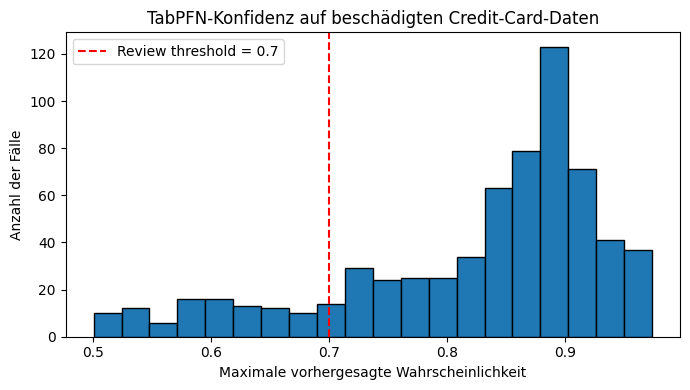

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Verteilung der maximalen Modellkonfidenz darstellen
plt.figure(figsize=(7, 4))
plt.hist(uncertain_cases_sorted["max_probability"], bins=20, edgecolor="black")
plt.axvline(threshold, color="red", linestyle="--", label=f"Review threshold = {threshold}")
plt.xlabel("Maximale vorhergesagte Wahrscheinlichkeit")
plt.ylabel("Anzahl der Fälle")
plt.title("TabPFN-Konfidenz auf beschädigten Credit-Card-Daten")
plt.legend()
plt.tight_layout()

figure_file = "chapter07_tabpfn_confidence_distribution.png"
plt.savefig(figure_file, dpi=180)
plt.show()

files.download(figure_file)

In [ ]:
# Kopie des beschädigten Datensatzes erstellen
df_tabpfn_cleaned = df.copy()

# Review-Fälle aus TabPFN übernehmen
review_cases = uncertain_cases_sorted[
    uncertain_cases_sorted["needs_review"] == True
].copy()

print("Review cases from TabPFN:", len(review_cases))

Review cases from TabPFN: 102


In [ ]:
# Da die ID-Spalte vor dem Training entfernt wurde, wird über den Index markiert.
# Deshalb verwenden wir die ursprünglichen Indizes aus X_test und uncertain_cases_sorted.

df_tabpfn_cleaned["tabpfn_needs_review"] = False

# Indizes der unsicheren Fälle markieren
review_indices = review_cases.index

df_tabpfn_cleaned.loc[
    df_tabpfn_cleaned.index.isin(review_indices),
    "tabpfn_needs_review"
] = True

print("Rows marked for review:", int(df_tabpfn_cleaned["tabpfn_needs_review"].sum()))

Rows marked for review: 102


In [ ]:
# Zeilen mit fehlender Zielvariable entfernen
df_tabpfn_cleaned = df_tabpfn_cleaned.dropna(subset=[target_col])

# Zielvariable als Integer setzen
df_tabpfn_cleaned[target_col] = df_tabpfn_cleaned[target_col].astype(int)

# Numerische und kategoriale Spalten trennen
numeric_cols = df_tabpfn_cleaned.select_dtypes(include="number").columns
categorical_cols = df_tabpfn_cleaned.select_dtypes(exclude="number").columns

# Zielspalte nicht imputieren
numeric_cols = [col for col in numeric_cols if col != target_col]

# Fehlende numerische Werte mit Median ersetzen
num_imputer = SimpleImputer(strategy="median")
df_tabpfn_cleaned[numeric_cols] = num_imputer.fit_transform(
    df_tabpfn_cleaned[numeric_cols]
)

# Fehlende kategoriale Werte mit "unknown" ersetzen
for col in categorical_cols:
    df_tabpfn_cleaned[col] = df_tabpfn_cleaned[col].fillna("unknown")

print("Missing values after cleaning:", int(df_tabpfn_cleaned.isna().sum().sum()))
print("Rows marked for review:", int(df_tabpfn_cleaned["tabpfn_needs_review"].sum()))

Missing values after cleaning: 0
Rows marked for review: 102


In [ ]:
# Dateinamen definieren
output_file = "chapter07_tabpfn_supported_cleaned_data.xlsx"
review_file = "chapter07_tabpfn_review_cases.xlsx"

# Bereinigten Datensatz speichern
df_tabpfn_cleaned.to_excel(output_file, index=False)

# Nur Review-Fälle separat speichern
df_tabpfn_cleaned[df_tabpfn_cleaned["tabpfn_needs_review"] == True].to_excel(
    review_file,
    index=False
)

# Dateien herunterladen
files.download(output_file)
files.download(review_file)

print("Saved:", output_file)
print("Saved:", review_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved: chapter07_tabpfn_supported_cleaned_data.xlsx
Saved: chapter07_tabpfn_review_cases.xlsx
